In [10]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

CUDA available: True
GPU count: 2


In [11]:
import os
print("CPU cores:", os.cpu_count())

CPU cores: 4


In [12]:
!pip install -q PyMuPDF pillow sentence-transformers faiss-cpu \
    scikit-learn pandas numpy tqdm kagglehub easyocr
!pip install -q huggingface_hub

In [ ]:
from huggingface_hub import login

login(os.environ["HF_TOKEN"]) # Make sure to set your Hugging Face token in the environment variable HF_TOKEN before running this code.

In [14]:
from huggingface_hub import HfApi

api = HfApi()

HF_REPO = "alirou3/resumee"

def upload_checkpoint(local_path):
    api.upload_file(
        path_or_fileobj=str(local_path),
        path_in_repo=local_path.name,
        repo_id=HF_REPO,
        repo_type="dataset",
    )
    print(f"Uploaded {local_path.name} to Hugging Face")

In [15]:
import pathlib
import kagglehub

dataset_path = kagglehub.dataset_download("hadikp/resume-data-pdf")
print("Path to dataset files:", dataset_path)

RAW_DATA_DIR = pathlib.Path(dataset_path)
# If the download extracts into a subfolder, point at it directly, e.g.:
# RAW_DATA_DIR = pathlib.Path(dataset_path) / "Resumes PDF"
print(list(RAW_DATA_DIR.iterdir())[:5])


Path to dataset files: /kaggle/input/datasets/hadikp/resume-data-pdf
[PosixPath('/kaggle/input/datasets/hadikp/resume-data-pdf/Resumes PDF')]


In [16]:
%%writefile ocr_workers.py
"""
Worker functions for the OCR pipeline, written to disk so multiprocessing's
'spawn' start method (required for CUDA-using workers) can import them.
"""
import os
import io
import fitz  # PyMuPDF
import numpy as np
from PIL import Image
import torch

ZOOM = 2.0
MIN_DIRECT_TEXT_LEN = 20
NUM_GPUS = max(1, torch.cuda.device_count())

# ============================================================
# CPU STAGE: render pages (no CUDA touched here -> fork-safe)
# ============================================================
def render_pdf(args):
    rec_id, category, path = args
    try:
        doc = fitz.open(path)
        pages = []
        for page in doc:
            text = page.get_text("text").strip()
            if len(text) >= MIN_DIRECT_TEXT_LEN:
                pages.append({"text": text, "needs_ocr": False})
            else:
                mat = fitz.Matrix(ZOOM, ZOOM)
                pix = page.get_pixmap(matrix=mat)
                img = Image.frombytes("RGB", (pix.width, pix.height), pix.samples)
                buf = io.BytesIO()
                img.save(buf, format="PNG")
                pages.append({"text": None, "needs_ocr": True, "png": buf.getvalue()})
        doc.close()
        return {"id": rec_id, "category": category, "path": str(path),
                "pages": pages, "error": None}
    except Exception as e:
        return {"id": rec_id, "category": category, "path": str(path),
                "pages": [], "error": str(e)}


def iter_resume_files(root):
    import pathlib
    root = pathlib.Path(root)
    for category_dir in sorted(root.iterdir()):
        if not category_dir.is_dir():
            continue
        for pdf_path in sorted(category_dir.rglob("*.pdf")):
            yield category_dir.name, pdf_path


# ============================================================
# GPU STAGE: one EasyOCR model per worker process, pinned to one GPU
# ============================================================
_ocr_engine = None

def init_gpu_worker():
    global _ocr_engine
    import multiprocessing as mp
    worker_idx = (mp.current_process()._identity[0] - 1) % NUM_GPUS
    os.environ["CUDA_VISIBLE_DEVICES"] = str(worker_idx)
    import easyocr
    _ocr_engine = easyocr.Reader(['en'], gpu=True)
    print(f"[GPU worker {worker_idx}] EasyOCR loaded on GPU {worker_idx}")


def gpu_ocr_worker(task):
    global _ocr_engine
    rendered_index, page_items = task
    out = []
    for page_idx, png_bytes in page_items:
        img = Image.open(io.BytesIO(png_bytes)).convert("RGB")
        lines_ = _ocr_engine.readtext(np.array(img), detail=0, paragraph=True)
        out.append((page_idx, "\n".join(lines_)))
    return rendered_index, out


Overwriting ocr_workers.py


In [17]:
import pathlib, json, os, multiprocessing as mp
from tqdm.auto import tqdm
import sys
sys.path.insert(0, ".")
from ocr_workers import render_pdf, iter_resume_files, init_gpu_worker, gpu_ocr_worker, NUM_GPUS

CHECKPOINT_DIR = pathlib.Path("./checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)
CHECKPOINT_EVERY = 500
CPU_WORKERS = os.cpu_count()

print(f"Using {NUM_GPUS} GPU(s) for OCR, {CPU_WORKERS} CPU workers for rendering")

def load_existing_progress():
    records, done_ids = [], set()
    checkpoints = sorted(CHECKPOINT_DIR.glob('checkpoint_*.json'),
                          key=lambda p: int(p.stem.split('_')[1]))
    if checkpoints:
        latest = checkpoints[-1]
        with open(latest) as f:
            records = json.load(f)
        done_ids = {r["id"] for r in records}
        print(f"Resuming from {latest.name}: {len(records)} already done")
    return records, done_ids

all_files = list(iter_resume_files(RAW_DATA_DIR))
print(f"Found {len(all_files)} PDFs across {len({c for c, _ in all_files})} category folders")

records, done_ids = load_existing_progress()

jobs = []
for i, (category, pdf_path) in enumerate(all_files):
    rec_id = f"{category.lower().replace(' ', '_')}_{i:05d}"
    if rec_id in done_ids:
        continue
    jobs.append((rec_id, category, pdf_path))
print(f"{len(jobs)} PDFs remaining")

gpu_ctx = mp.get_context("spawn")
gpu_pool = gpu_ctx.Pool(processes=NUM_GPUS, initializer=init_gpu_worker)

try:
    for chunk_start in range(0, len(jobs), CHECKPOINT_EVERY):
        chunk = jobs[chunk_start: chunk_start + CHECKPOINT_EVERY]

        with mp.Pool(CPU_WORKERS) as cpu_pool:
            rendered = list(tqdm(
                cpu_pool.imap_unordered(render_pdf, chunk),
                total=len(chunk),
                desc=f"Rendering {chunk_start}-{chunk_start + len(chunk)}"
            ))

        tasks = []
        for idx, res in enumerate(rendered):
            if res["error"]:
                continue
            needs = [(pi, p["png"]) for pi, p in enumerate(res["pages"]) if p["needs_ocr"]]
            if needs:
                tasks.append((idx, needs))

        ocr_results = {}
        for rendered_index, page_results in tqdm(
            gpu_pool.imap_unordered(gpu_ocr_worker, tasks),
            total=len(tasks), desc=f"OCR ({NUM_GPUS}x GPU)"
        ):
            ocr_results[rendered_index] = dict(page_results)

        for idx, res in enumerate(rendered):
            if res["error"]:
                print(f"Failed {res['path']}: {res['error']}")
                continue
            page_texts = []
            ocr_map = ocr_results.get(idx, {})
            n_ocr = 0
            for pi, p in enumerate(res["pages"]):
                if p["needs_ocr"]:
                    page_texts.append(ocr_map.get(pi, ""))
                    n_ocr += 1
                else:
                    page_texts.append(p["text"])
            full_text = "\n".join(t for t in page_texts if t).strip()
            records.append({
                "id": res["id"],
                "category_raw": res["category"],
                "file_path": res["path"],
                "text": full_text,
                "num_pages": len(res["pages"]),
                "ocr_pages": n_ocr,
            })

        # Save checkpoint
        ckpt_path = CHECKPOINT_DIR / f"checkpoint_{len(records)}.json"

        with open(ckpt_path, "w") as f:
            json.dump(records, f)

        print(f"Checkpoint saved: {ckpt_path.name}")

        upload_checkpoint(ckpt_path)

finally:
    gpu_pool.close()
    gpu_pool.join()

print(f"Extracted {len(records)} resumes")

Using 2 GPU(s) for OCR, 4 CPU workers for rendering
Found 8905 PDFs across 1 category folders
8905 PDFs remaining


Rendering 0-500:   0%|          | 0/500 [00:00<?, ?it/s]

OCR (2x GPU):   0%|          | 0/500 [00:00<?, ?it/s]

Checkpoint saved: checkpoint_500.json
Uploaded checkpoint_500.json to Hugging Face


Rendering 500-1000:   0%|          | 0/500 [00:00<?, ?it/s]

...

OCR (2x GPU):   0%|          | 0/405 [00:00<?, ?it/s]

Checkpoint saved: checkpoint_8905.json


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded checkpoint_8905.json to Hugging Face
[GPU worker 0] EasyOCR loaded on GPU 0
[GPU worker 1] EasyOCR loaded on GPU 1
Extracted 8905 resumes


In [18]:
from pathlib import Path

out = Path("/kaggle/working/output")

print("Output directory exists:", out.exists())

if out.exists():
    print("\nFiles:")
    for f in sorted(out.iterdir()):
        print("-", f.name, f.stat().st_size, "bytes")

Output directory exists: False


In [19]:
from pathlib import Path

for f in Path("/kaggle/working").rglob("*.json"):
    print(f)

/kaggle/working/checkpoints/checkpoint_3000.json
/kaggle/working/checkpoints/checkpoint_1000.json
/kaggle/working/checkpoints/checkpoint_4500.json
/kaggle/working/checkpoints/checkpoint_7000.json
/kaggle/working/checkpoints/checkpoint_1500.json
/kaggle/working/checkpoints/checkpoint_8000.json
/kaggle/working/checkpoints/checkpoint_6000.json
/kaggle/working/checkpoints/checkpoint_8905.json
/kaggle/working/checkpoints/checkpoint_8500.json
/kaggle/working/checkpoints/checkpoint_5000.json
/kaggle/working/checkpoints/checkpoint_5500.json
/kaggle/working/checkpoints/checkpoint_2000.json
/kaggle/working/checkpoints/checkpoint_3500.json
/kaggle/working/checkpoints/checkpoint_500.json
/kaggle/working/checkpoints/checkpoint_7500.json
/kaggle/working/checkpoints/checkpoint_6500.json
/kaggle/working/checkpoints/checkpoint_2500.json
/kaggle/working/checkpoints/checkpoint_4000.json


In [24]:
import re
from pathlib import Path

CATEGORY_ALIASES = {
    "hr": "HR",
    "human resources": "HR",
    "hr resumes": "HR",

    "it": "Information Technology",
    "information technology": "Information Technology",
    "information technology resumes": "Information Technology",

    "accountant": "Accountant",
    "accountant resumes": "Accountant",

    "advocate": "Advocate",
    "advocate resumes": "Advocate",

    "agriculture": "Agriculture",
    "agricultural": "Agriculture",
    "agricultural resumes": "Agriculture",

    "apparel": "Apparel",
    "apparel resumes": "Apparel",

    "architect": "Architect",
    "architects": "Architect",
    "architects resumes": "Architect",

    "arts": "Arts",
    "arts resumes": "Arts",

    "automobile": "Automobile",
    "automobile resumes": "Automobile",

    "aviation": "Aviation",
    "aviation resumes": "Aviation",

    "banking": "Banking",
    "banking resumes": "Banking",

    "blockchain": "Blockchain",
    "blockchain resumes": "Blockchain",

    "bpo": "BPO",
    "bpo resumes": "BPO",

    "building construction": "Building Construction",
    "building_construction": "Building Construction",
    "building_construction resumes": "Building Construction",

    "business analyst": "Business Analyst",
    "business analyst resumes": "Business Analyst",

    "civil engineer": "Civil Engineer",
    "civilengineer": "Civil Engineer",
    "civil engineer resumes": "Civil Engineer",

    "consult": "Consultant",
    "consultant": "Consultant",
    "consultant resumes": "Consultant",

    "data science": "Data Science",
    "datascience": "Data Science",
    "data science resumes": "Data Science",

    "database": "Database",
    "database resumes": "Database",

    "design": "Design",
    "designer": "Design",
    "designing": "Design",
    "designing resumes": "Design",

    "devops engineer": "DevOps Engineer",
    "devopsengineer": "DevOps Engineer",
    "devops engineer resumes": "DevOps Engineer",

    "digital": "Digital Media",
    "digital media": "Digital Media",
    "digital media resumes": "Digital Media",

    "dotnet": ".NET Developer",
    "dotnet developer": ".NET Developer",
    "dotnet developer resumes": ".NET Developer",

    "education": "Education",
    "education resumes": "Education",

    "electrical engineer": "Electrical Engineer",
    "electricalengineer": "Electrical Engineer",
    "electrical engineering resumes": "Electrical Engineer",

    "etl": "ETL Developer",
    "etl developer": "ETL Developer",
    "etl developer resumes": "ETL Developer",

    "finance": "Finance",
    "finance resumes": "Finance",

    "food": "Food",
    "food_beverages": "Food",
    "food_beverages resumes": "Food",

    "healthfitness": "Health & Fitness",
    "health_fitness": "Health & Fitness",
    "health_fitness resumes": "Health & Fitness",

    "java developer": "Java Developer",
    "javadeveloper": "Java Developer",
    "java developer resumes": "Java Developer",

    "management": "Management",
    "management resumes": "Management",

    "mechanical engineer": "Mechanical Engineer",
    "mechanicalengineer": "Mechanical Engineer",
    "mechanical engineer resumes": "Mechanical Engineer",

    "nse": "Network Security Engineer",
    "network security engineer": "Network Security Engineer",
    "network security engineer resumes": "Network Security Engineer",

    "operationmanager": "Operations Manager",
    "operations manager": "Operations Manager",
    "operations manager resumes": "Operations Manager",

    "pmo": "PMO",
    "pmo resumes": "PMO",

    "public": "Public Relations",
    "public relations": "Public Relations",
    "public relations resumes": "Public Relations",

    "python developer": "Python Developer",
    "pythondeveloper": "Python Developer",
    "python developer resumes": "Python Developer",

    "react": "React Developer",
    "react developer": "React Developer",
    "react developer resumes": "React Developer",

    "sales": "Sales",
    "sales resumes": "Sales",

    "sap developer": "SAP Developer",
    "sapdeveloper": "SAP Developer",
    "sap developer resumes": "SAP Developer",

    "sql": "SQL Developer",
    "sql developer": "SQL Developer",
    "sql developer resumes": "SQL Developer",

    "testing": "Testing",
    "testing resumes": "Testing",

    "webdesigning": "Web Designing",
    "web designing": "Web Designing",
    "web designing resumes": "Web Designing",
}

WHITESPACE_RE = re.compile(r"\s+")
BULLET_RE = re.compile(r"[•●▪◦·]")
CONTROL_CHARS_RE = re.compile(r"[\x00-\x08\x0b\x0c\x0e-\x1f]")

def clean_text(text):
    text = CONTROL_CHARS_RE.sub(" ", text)
    text = BULLET_RE.sub("-", text)
    text = WHITESPACE_RE.sub(" ", text)
    return text.strip()

def normalize_category(raw):
    key = raw.strip().lower().replace("_", " ")
    return CATEGORY_ALIASES.get(key, raw.strip().replace("_", " ").title())

cleaned = []

for r in records:

    text = clean_text(r["text"])

    if len(text) < 50:
        continue

    # Recover category from folder name
    folder = Path(r["file_path"]).parent.name

    r["text"] = text
    r["category"] = normalize_category(folder)

    cleaned.append(r)

categories = sorted({r["category"] for r in cleaned})

print(f"Cleaned {len(cleaned)} resumes into {len(categories)} categories")
print(categories)

Cleaned 8874 resumes into 49 categories
['.NET Developer', 'Accountant', 'Advocate', 'Agriculture', 'Apparel', 'Architect', 'Arts', 'Automobile', 'Aviation', 'BPO', 'Banking', 'Blockchain', 'Building  Construction Resumes', 'Business Analyst', 'Businessanalyst', 'Civil Engineer', 'Consultant', 'Data Science', 'Database', 'Design', 'DevOps Engineer', 'Digital Media', 'Dot', 'ETL Developer', 'Education', 'Electrical Engineer', 'Finance', 'Food', 'Food Beverages Resumes', 'HR', 'Health & Fitness', 'Health Fitness Resumes', 'Information Technology', 'Java Developer', 'Management', 'Managment Resumes', 'Mechanical Engineer', 'Network Security Engineer', 'Operations Manager', 'PMO', 'Pbo', 'Public Relations', 'Python Developer', 'React Developer', 'SAP Developer', 'SQL Developer', 'Sales', 'Testing', 'Web Designing']


In [25]:
print(records[0])

{'id': 'resumes_pdf_00003', 'category_raw': 'Resumes PDF', 'file_path': '/kaggle/input/datasets/hadikp/resume-data-pdf/Resumes PDF/Accountant/0452d98376727179.pdf', 'text': 'Prolile Expctierxed Jrd dedicalcd Scllor ACcOUntaat bringile totth Sevcr lvears 6l vohusble industry caperkence und coinir Ient to providing vuety or fimanci and analytical tcvlcm scnres t0 company ecpartmcntsand clicnts Adcot In ensutlng comoliance wkth accounting princtole $ d (edery and state repulatlons Howard Jones Ilnior Accouniani Employment History Senlor Accountant , Addco Resources NEw York Dctnils 768 Nedii FhieerWay N Yol Ny10458 Urecd Sutct [2171231-2110 Lncctbdekmkcom Controlkcd dally Input ot Icdect activtice an d cloxing of Gencml rdgrt cach Montn Pre uued Jcumle quHerly ad wnhudstuicmnls Prenxredannual juditcd financhxsnicinents Woded dosthy wlth oltar rparunents and worked {0 solve cartiplet Kcountng probkins Provlded comm nteanJsk of Actual resuls% > Foce cast Throughoutthe Fenea Ensured udherenk

In [46]:
import random
from collections import defaultdict

random.seed(42)
by_category = defaultdict(list)
for r in cleaned:
    by_category[r["category"]].append(r)

train_records, val_records = [], []
VAL_FRACTION = 0.2

for cat, recs in by_category.items():
    random.shuffle(recs)
    n_val = max(1, int(len(recs) * VAL_FRACTION)) if len(recs) > 1 else 0
    val_records.extend(recs[:n_val])
    train_records.extend(recs[n_val:])

print(f"Train: {len(train_records)}  Val: {len(val_records)}")


Train: 7121  Val: 1753


In [48]:
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
import itertools, random

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
model = SentenceTransformer(EMBEDDING_MODEL_NAME)

# Build positive pairs: two different resumes from the same category
train_examples = []
by_cat_train = defaultdict(list)
for r in train_records:
    by_cat_train[r["category"]].append(r["text"])

random.seed(42)
MAX_PAIRS_PER_CATEGORY = 200  # cap so huge categories don't dominate

for cat, texts in by_cat_train.items():
    if len(texts) < 2:
        continue
    pairs = list(itertools.combinations(range(len(texts)), 2))
    random.shuffle(pairs)
    for i, j in pairs[:MAX_PAIRS_PER_CATEGORY]:
        train_examples.append(InputExample(texts=[texts[i][:1000], texts[j][:1000]]))

print(f"Built {len(train_examples)} training pairs across {len(by_cat_train)} categories")

train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=32)
train_loss = losses.MultipleNegativesRankingLoss(model)

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=50,
    warmup_steps=int(0.1 * len(train_dataloader)),
    show_progress_bar=True,
)

FINE_TUNED_PATH = "./resume_embedder_finetuned"
model.save(FINE_TUNED_PATH)
print(f"Saved fine-tuned model to {FINE_TUNED_PATH}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Currently using DataParallel (DP) for multi-gpu training, while DistributedDataParallel (DDP) is recommended for faster training. See https://sbert.net/docs/sentence_transformer/training/distributed.html for more information.


Built 9800 training pairs across 49 categories


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,1.627315
1000,1.131541
1500,0.972854
2000,0.873988
2500,0.795644
3000,0.739613
3500,0.694750
4000,0.648511
4500,0.618122
5000,0.586439


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved fine-tuned model to ./resume_embedder_finetuned


In [49]:
import faiss
import numpy as np

EMBEDDING_DIM = 384  # all-MiniLM-L6-v2 output dim; update if you swap models

all_texts = [r["text"] for r in cleaned]
embeddings = model.encode(
    all_texts, batch_size=32, show_progress_bar=True,
    convert_to_numpy=True, normalize_embeddings=True,
).astype("float32")

index = faiss.IndexFlatIP(EMBEDDING_DIM)  # inner product on normalized vecs == cosine similarity
index.add(embeddings)

metadata = [{"id": r["id"], "category": r["category"], "file_path": r["file_path"], "text": r["text"]} for r in cleaned]

faiss.write_index(index, "resumes.faiss")
with open("metadata.jsonl", "w", encoding="utf-8") as f:
    for m in metadata:
        f.write(json.dumps(m, ensure_ascii=False) + "\n")

print(f"Indexed {index.ntotal} resumes")


Batches:   0%|          | 0/278 [00:00<?, ?it/s]

Indexed 8874 resumes


In [50]:
from sentence_transformers import CrossEncoder

CROSS_ENCODER_MODEL = "cross-encoder/ms-marco-MiniLM-L-6-v2"
cross_encoder = CrossEncoder(CROSS_ENCODER_MODEL)

def embed_query(text):
    return model.encode([text], normalize_embeddings=True, convert_to_numpy=True).astype("float32")

def retrieve(job_description, top_k=50):
    query_vec = embed_query(job_description)
    scores, idxs = index.search(query_vec, top_k)
    out = []
    for score, idx in zip(scores[0], idxs[0]):
        if idx == -1:
            continue
        rec = dict(metadata[idx])
        rec["cosine_score"] = float(score)
        out.append(rec)
    return out

def rerank(job_description, candidates, top_k=10):
    if not candidates:
        return []
    pairs = [(job_description, c["text"][:2000]) for c in candidates]
    scores = cross_encoder.predict(pairs)
    for c, s in zip(candidates, scores):
        c["rerank_score"] = float(s)
    return sorted(candidates, key=lambda c: c["rerank_score"], reverse=True)[:top_k]

def match(job_description, retrieve_k=50, return_k=10, category_filter=None):
    candidates = retrieve(job_description, top_k=retrieve_k)
    if category_filter:
        candidates = [c for c in candidates if c["category"] == category_filter]
    return rerank(job_description, candidates, top_k=return_k)

# quick smoke test
demo_jd = (
    "We are looking for a Senior Software Engineer with 5+ years of experience "
    "in Python, distributed systems, and cloud infrastructure (AWS or GCP)."
)
for r in match(demo_jd):
    print(f"{r['rerank_score']:.3f}  {r['category']:<25} {r['id']}")


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


3.802  Python Developer          resumes_pdf_07553
2.557  Python Developer          resumes_pdf_07534
0.920  DevOps Engineer           resumes_pdf_03945
0.834  Python Developer          resumes_pdf_07435
0.630  React Developer           resumes_pdf_07759
-0.043  Python Developer          resumes_pdf_07447
-0.530  Network Security Engineer resumes_pdf_06873
-0.662  DevOps Engineer           resumes_pdf_03843
-0.912  Python Developer          resumes_pdf_07467
-1.050  React Developer           resumes_pdf_07664


In [51]:
import numpy as np

def precision_at_k(relevant_flags, k):
    return sum(relevant_flags[:k]) / k

def recall_at_k(relevant_flags, k, total_relevant):
    if total_relevant == 0:
        return 0.0
    return sum(relevant_flags[:k]) / total_relevant

def reciprocal_rank(relevant_flags):
    for i, flag in enumerate(relevant_flags, start=1):
        if flag:
            return 1.0 / i
    return 0.0

def dcg_at_k(relevant_flags, k):
    return sum(
        rel / np.log2(i + 2) for i, rel in enumerate(relevant_flags[:k])
    )

def ndcg_at_k(relevant_flags, k, total_relevant):
    ideal = [1] * min(total_relevant, k) + [0] * max(0, k - total_relevant)
    idcg = dcg_at_k(ideal, k)
    if idcg == 0:
        return 0.0
    return dcg_at_k(relevant_flags, k) / idcg

K_VALUES = [5, 10]
category_counts = {cat: sum(1 for r in cleaned if r["category"] == cat) for cat in categories}

results = {k: {"precision": [], "recall": [], "ndcg": []} for k in K_VALUES}
mrr_scores = []

EVAL_SAMPLE_SIZE = min(200, len(val_records))  # cap eval set size for speed; raise if you have time
eval_records = random.sample(val_records, EVAL_SAMPLE_SIZE)

for r in tqdm(eval_records, desc="Evaluating"):
    query_text = r["text"][:1500]
    query_category = r["category"]
    total_relevant_in_corpus = category_counts[query_category] - 1  # exclude the query itself

    candidates = retrieve(query_text, top_k=max(K_VALUES) + 5)
    candidates = [c for c in candidates if c["id"] != r["id"]]  # drop self-match
    ranked = rerank(query_text, candidates, top_k=max(K_VALUES))

    relevant_flags = [1 if c["category"] == query_category else 0 for c in ranked]

    mrr_scores.append(reciprocal_rank(relevant_flags))
    for k in K_VALUES:
        results[k]["precision"].append(precision_at_k(relevant_flags, k))
        results[k]["recall"].append(recall_at_k(relevant_flags, k, total_relevant_in_corpus))
        results[k]["ndcg"].append(ndcg_at_k(relevant_flags, k, total_relevant_in_corpus))

print("=== Metrics report ===")
print(f"MRR: {np.mean(mrr_scores):.4f}")
for k in K_VALUES:
    print(f"Precision@{k}: {np.mean(results[k]['precision']):.4f}   "
          f"Recall@{k}: {np.mean(results[k]['recall']):.4f}   "
          f"NDCG@{k}: {np.mean(results[k]['ndcg']):.4f}")


Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

=== Metrics report ===
MRR: 0.9321
Precision@5: 0.8930   Recall@5: 0.0243   NDCG@5: 0.8980
Precision@10: 0.8795   Recall@10: 0.0476   NDCG@10: 0.8868


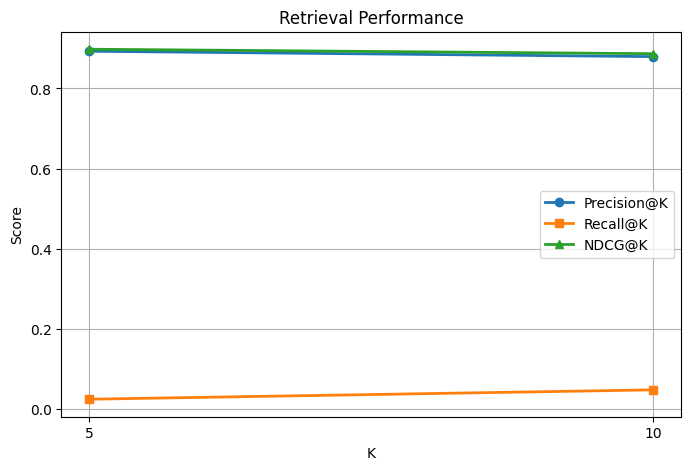

In [52]:
import matplotlib.pyplot as plt
import numpy as np

ks = K_VALUES

precision = [np.mean(results[k]["precision"]) for k in ks]
recall = [np.mean(results[k]["recall"]) for k in ks]
ndcg = [np.mean(results[k]["ndcg"]) for k in ks]

plt.figure(figsize=(8,5))

plt.plot(ks, precision, marker="o", linewidth=2, label="Precision@K")
plt.plot(ks, recall, marker="s", linewidth=2, label="Recall@K")
plt.plot(ks, ndcg, marker="^", linewidth=2, label="NDCG@K")

plt.xlabel("K")
plt.ylabel("Score")
plt.title("Retrieval Performance")
plt.xticks(ks)
plt.grid(True)
plt.legend()

plt.show()

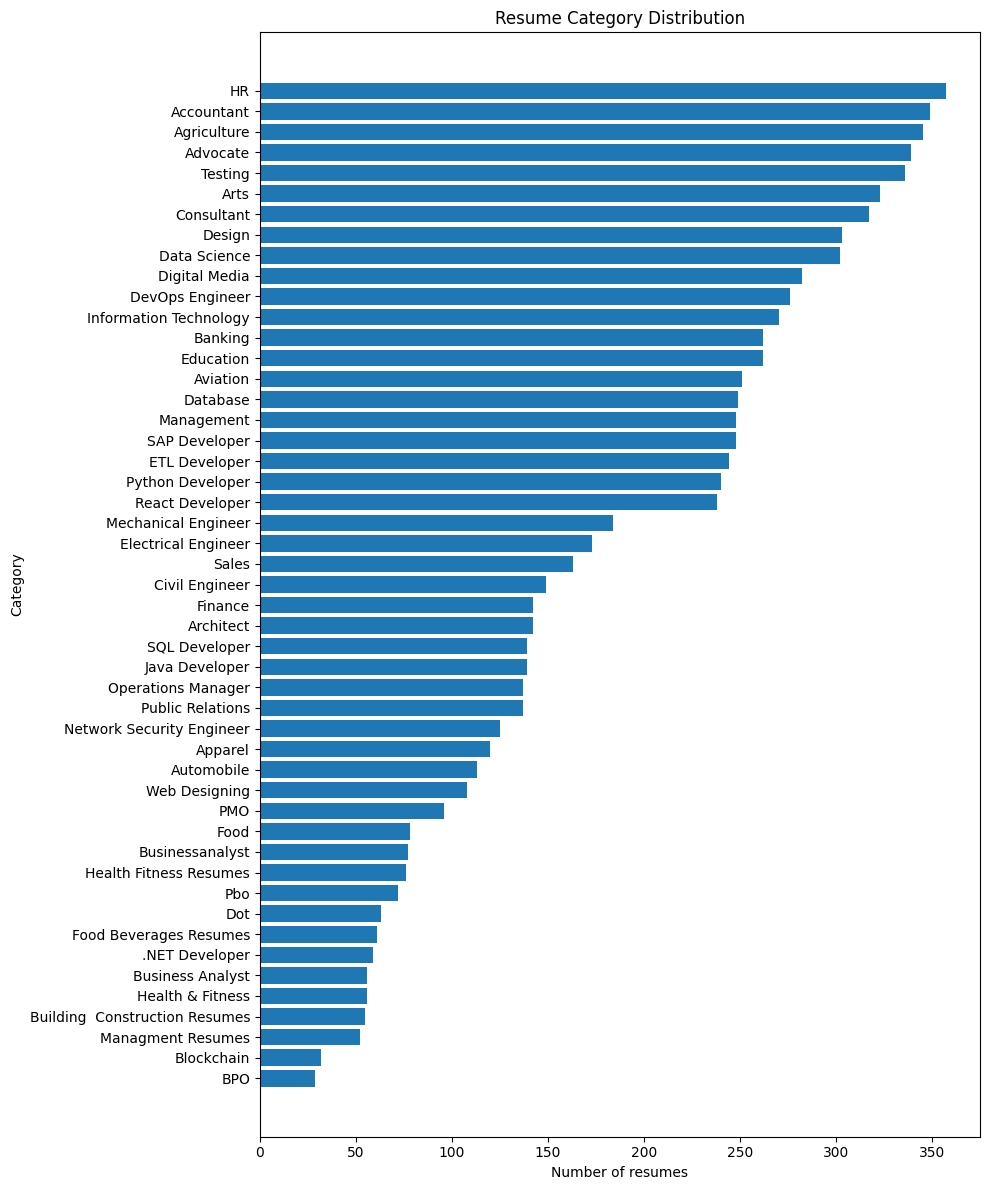

In [53]:
import matplotlib.pyplot as plt
from collections import Counter

cat_counts = Counter(r["category"] for r in cleaned)

cats = list(cat_counts.keys())
counts = list(cat_counts.values())

order = np.argsort(counts)

cats = np.array(cats)[order]
counts = np.array(counts)[order]

plt.figure(figsize=(10,12))

plt.barh(cats, counts)

plt.xlabel("Number of resumes")
plt.ylabel("Category")
plt.title("Resume Category Distribution")

plt.tight_layout()
plt.show()

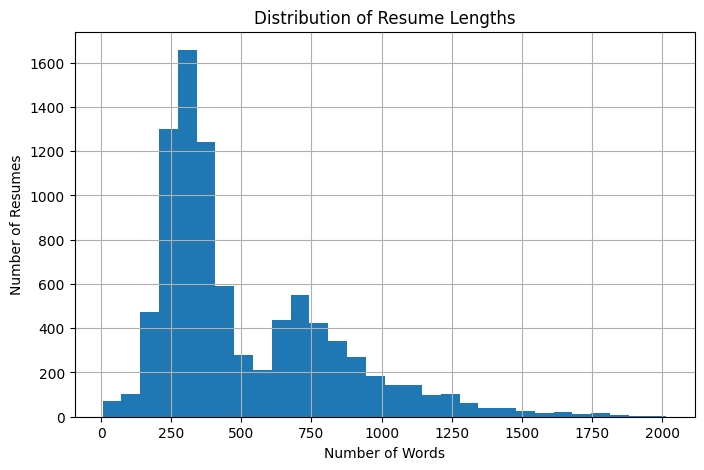

In [54]:
import matplotlib.pyplot as plt

lengths = [len(r["text"].split()) for r in cleaned]

plt.figure(figsize=(8,5))

plt.hist(lengths, bins=30)

plt.xlabel("Number of Words")
plt.ylabel("Number of Resumes")
plt.title("Distribution of Resume Lengths")

plt.grid(True)

plt.show()

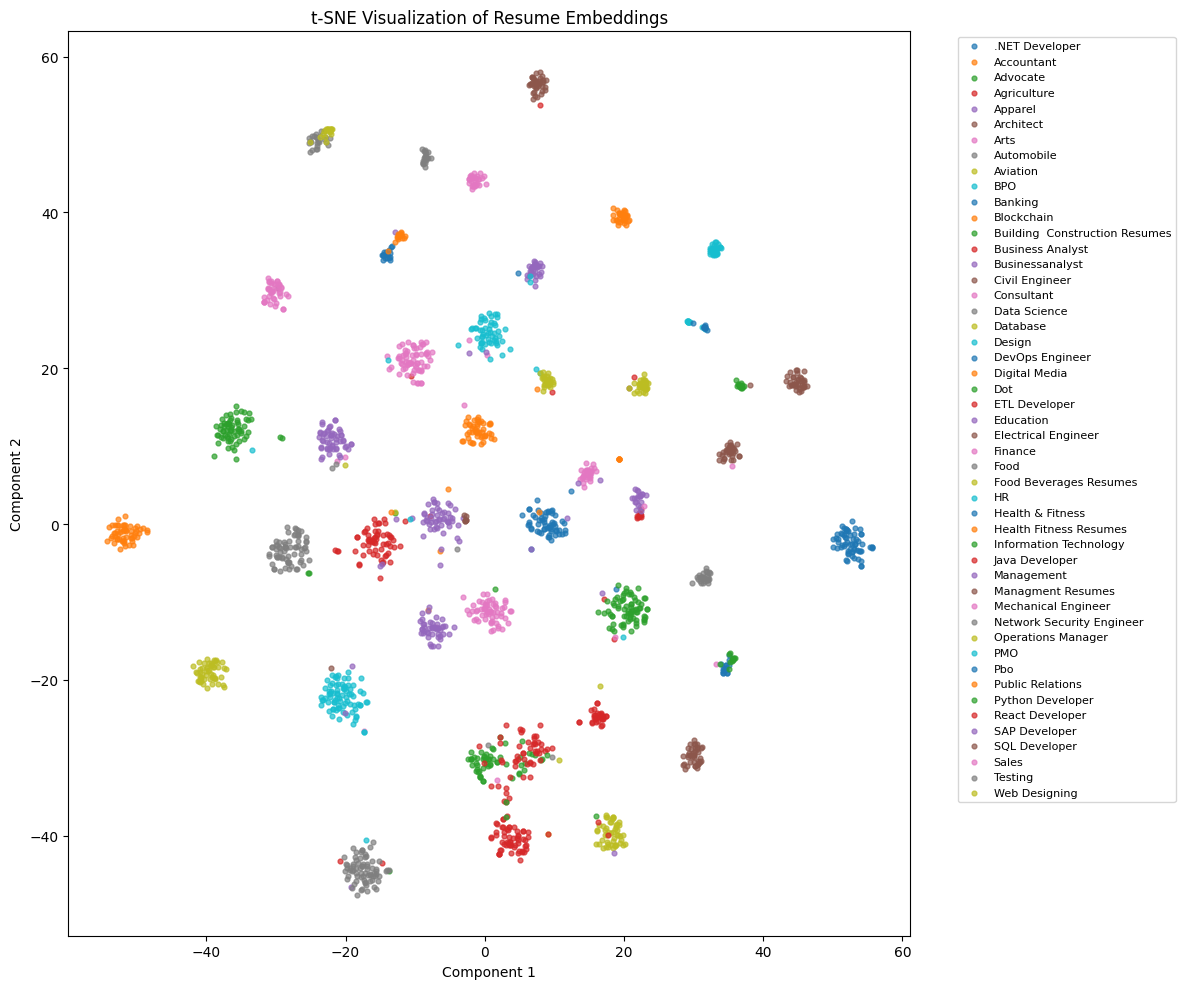

In [55]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import random

MAX_POINTS = 2000

if len(embeddings) > MAX_POINTS:
    idx = random.sample(range(len(embeddings)), MAX_POINTS)
else:
    idx = list(range(len(embeddings)))

sample_embeddings = embeddings[idx]
sample_labels = [cleaned[i]["category"] for i in idx]

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
)

coords = tsne.fit_transform(sample_embeddings)

unique_labels = sorted(set(sample_labels))

plt.figure(figsize=(12,10))

for label in unique_labels:
    mask = [l == label for l in sample_labels]
    plt.scatter(
        coords[mask,0],
        coords[mask,1],
        s=12,
        alpha=0.7,
        label=label
    )

plt.title("t-SNE Visualization of Resume Embeddings")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.show()